In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from var_definition import *

start_date = "2025-01-01"  # ou ce que tu avais défini
end_date   = "2025-10-01"  # adapte à ton besoin

dates_daily = pd.date_range(start=start_date, end=end_date, freq="D")


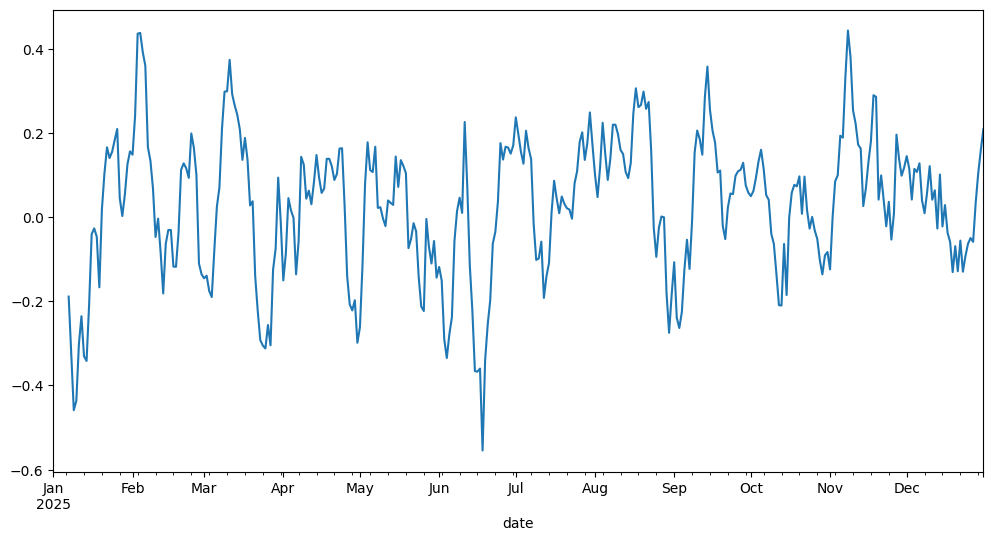

In [6]:
#Data preparation

sentiments = pd.read_csv("..\\..\\data\\news_processed\\aggregated_daily_finbert.csv", index_col=0, parse_dates=True)
sentiments['diff_ma7'].plot(figsize=(12, 6))

sent = sentiments['diff_ma7'].dropna()

<Axes: xlabel='observation_date'>

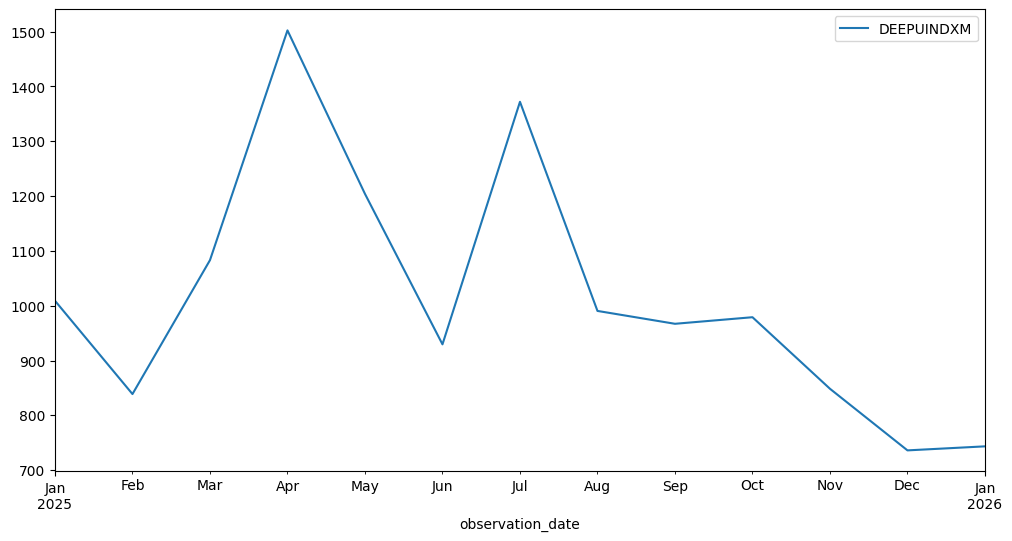

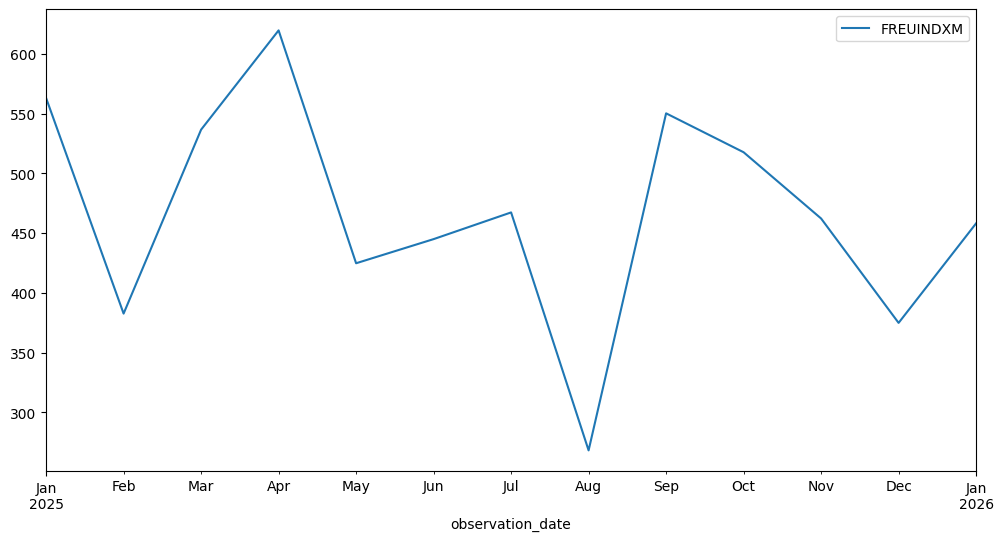

In [21]:
german_uncertainty = pd.read_csv("..\\..\\data\\other_indices\\DEEPUINDXM.csv", index_col=0, parse_dates=True)
german_uncertainty = german_uncertainty[german_uncertainty.index >= start_date]
german_uncertainty.plot(figsize=(12, 6))

french_uncertainty = pd.read_csv("..\\..\\data\\other_indices\\FREUINDXM.csv", index_col=0, parse_dates=True)
french_uncertainty = french_uncertainty[french_uncertainty.index >= start_date]
french_uncertainty.plot(figsize=(12, 6))

On veut maintenant certaines variables macro : PIB, Inflation, Dette, Spread OAT/Bund, Volatilité CAC40, Ecart des taux cours et long

In [ ]:
#UNETOT_FR : Total unemployment in France
#UNEO25_FR : Unemployment : Over 25 years in France
#UNEU25_FR : Unemployment : Under 25 years in France
#REER42_FR : Real Exchange Rate (42 main industrial countries)
#LTIRT_FR : Long-term interest rate in France (EMU Criterion)
#IPMN_FR : Industrial production index Manufacturing in France
#IPCAG_FR : Industrial Production Index: Capital Goods in France
#IPCOG_FR' : Industrial Production Index: Consumer Goods in France
#'IPDCOG_FR' : Industrial Production Index: Durable Consumer Goods, 
# 'IPNDCOG_FR' :  Industrial Production Index: Non Durable Consumer Goods,
#'IPING_FR' : Industrial Production Index: Intermediate Goods
#'IPNRG_FR' :  Industrial Production Index: Energy, 
#'TRNMN_FR' : Turnover Index: Manufacturing
#'TRNCAG_FR' : Turnover Index: Capital Goods, 
#'TRNCOG_FR' : Turnover Index: Consumer Goods,
#'TRNDCOG_FR' : Turnover Index: Durable Consumer Goods,
#'TRNNDCOG_FR' : Turnover Index: Non Durable Consumer Goods,
#'TRNING_FR' : Turnover Index: Intermediate Goods,
#'TRNNRG_FR' : Turnover Index: Energy,
#'PPICAG_FR' : Producer Price Index: Capital Goods,
#'PPICOG_FR' : Producer Price Index: Consumer Goods,
#'PPINDCOG_FR': Producer Price Index: Non Durable Consumer Goods
#'PPIDCOG_FR' : Producer Price Index: Durable Consumer Goods,
#'PPIING_FR' : Producer Price Index: Intermediate Goods,
#'PPINRG_FR' : Producer Price Index: Energy,
# 'HICPOV_FR' :  Harmonized Index of Consumer Prices: Overall Index 
# 'HICPNEF_FR' : Harmonized Index of Consumer Prices: All Items: no Energy & Food
# 'HICPG_FR' : Harmonized Index of Consumer Prices: Goods
# 'HICPIN_FR' : Harmonized Index of Consumer Prices: Industrial Goods
# 'HICPSV_FR' : Harmonized Index of Consumer Prices: Services
# 'HICPNG_FR' : Harmonized Index of Consumer Prices: Non-Industrial Goods
# 'SHIX_FR' : Share price index: CAC 40 in France

Index(['GDP_FR', 'EXPGS_FR', 'IMPGS_FR', 'GFCE_FR', 'HFCE_FR', 'CONSD_FR',
       'CONSSD_FR', 'CONSND_FR', 'CONSSV_FR', 'GCF_FR',
       ...
       'HICPNG_FR', 'ICONFIX_FR', 'CCONFIX_FR', 'ESENTIX_FR', 'KCONFIX_FR',
       'RTCONFIX_FR', 'SCONFIX_FR', 'BCI_FR', 'CCI_FR', 'SHIX_FR'],
      dtype='object', length=110)


C:\Users\elyan\AppData\Local\Temp\ipykernel_19024\2948650822.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .reindex(pd.date_range(macro_data_DE.index.min(), macro_data_DE.index.max(), freq="M"))


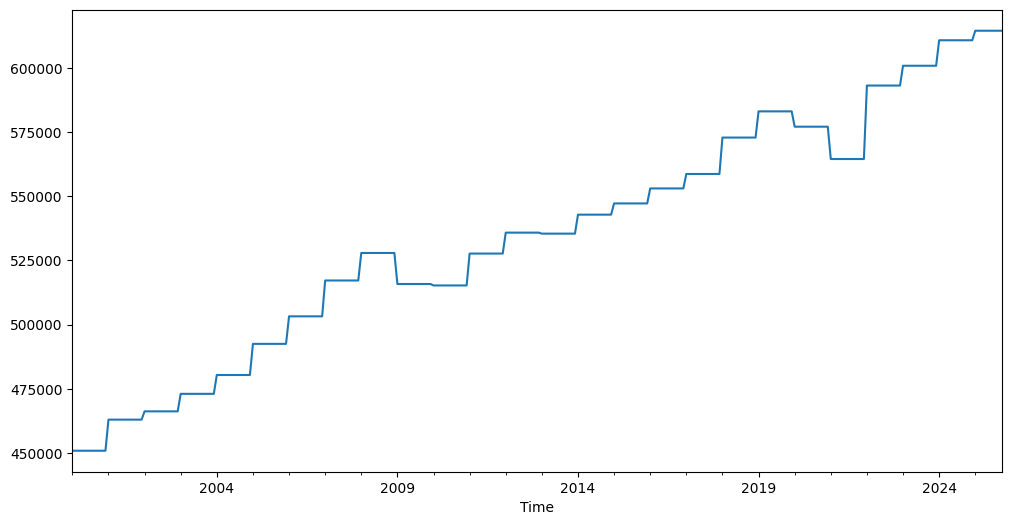

In [44]:
macro_data_FR = pd.read_excel("..\\..\\data\\processed\\FRdata_monthly.xlsx", index_col=0, parse_dates=True)
print(macro_data_FR.columns)
cols_to_keep = ['GDP_FR','SHIX_FR','LTIRT_FR'] #PIB, Prix actions, taux long #monthly
macro_data_FR = macro_data_FR[cols_to_keep]
macro_data_FR['GDP_FR'].plot(figsize=(12, 6))
macro_data_FR = macro_data_FR[macro_data_FR.index >= start_date]

macro_data_FR_daily = (
    macro_data_FR
    .reindex(dates_daily.union(macro_data_FR.index))
    .sort_index()
    .interpolate(method="time")
    .reindex(dates_daily)
)


macro_data_DE = pd.read_excel("..\\..\\data\\processed\\DEdata_monthly.xlsx", index_col=0, parse_dates=True)
cols_to_keep = ['GDP_DE','SHIX_DE','LTIRT_DE'] #PIB, Prix actions, taux long monthly
macro_data_DE = macro_data_DE[cols_to_keep]
macro_data_DE = macro_data_DE[macro_data_DE.index >= start_date]

macro_data_DE_daily = (
    macro_data_DE
    .reindex(pd.date_range(macro_data_DE.index.min(), macro_data_DE.index.max(), freq="M"))
    .reindex(dates_daily, method="nearest")
    .interpolate(method="linear")
)

french_short_rate = pd.read_csv("..\\..\\data\\short_rate\\FR_short.csv", index_col=0)
french_short_rate = french_short_rate['Dernier']


german_short_rate = pd.read_csv("..\\..\\data\\short_rate\\DE_short.csv", index_col=0)
german_short_rate = german_short_rate['Dernier'] #Daily
# French inflation 0.9% DE 2.2% 
# Dette France : 1er trimestre 2025 : 114 PIB, 2eme trimestre 2025 : 115.7 PIB, 3eme trimestre 2025 : 117.4 PIB, 4eme trimestre 2025 : 119.2 PIB (projection)
# Dette Allemagne : 1er trimestre 2025 : 62.0 PIB, 2eme trimestre 2025 : 62.3 PIB, 3eme trimestre 2025 : 63 PIB, 4eme trimestre 2025 : 63.2 PIB (projection)



french_monsual_inflation = (1 + 0.009) ** (1/12) - 1
german_monsual_inflation = (1 + 0.022) ** (1/12) - 1

french_debt = [114, 115.7, 117.4, 119.2]
german_debt = [62.0, 62.3, 63, 63.2]



In [42]:
macro_data_FR_daily
#macro_data_FR_daily['GDP_FR'].isna().sum()

,GDP_FR,SHIX_FR,LTIRT_FR
2025-01-01,614549.866667,151.813500,3.320000
2025-01-02,614549.866667,152.077984,3.314516
2025-01-03,614549.866667,152.342468,3.309032
2025-01-04,614549.866667,152.606952,3.303548
2025-01-05,614549.866667,152.871435,3.298065
...,...,...,...
2025-09-27,614549.866667,155.648500,3.510000
2025-09-28,614549.866667,155.648500,3.510000
2025-09-29,614549.866667,155.648500,3.510000
2025-09-30,614549.866667,155.648500,3.510000
